### 参数 + 使用的库

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


from scipy.integrate import quad
from scipy.optimize import brentq


# 1. 基本参数

PITCH = 0.55                 # 螺距，m

p = PITCH / (2 * np.pi)      # 阿基米德螺线参数 p

HEAD_LENGTH = 3.41           # 龙头长度，m
BODY_LENGTH = 2.20           # 龙身/龙尾长度，m
HOLE_OFFSET = 0.275          # 把手孔中心距板头，m
BOARD_WIDTH = 0.30           # 板凳宽度，m
HEAD_SPEED = 1.0             # 龙头前把手速度，m/s

N_HANDLES = 224              # 把手总数
BODY_HANDLE_DISTANCE = BODY_LENGTH - 2 * HOLE_OFFSET                             # 龙头前 + 龙头后 + 221节龙身相关 + 龙尾后
HEAD_HANDLE_DISTANCE = HEAD_LENGTH - 2 * HOLE_OFFSET

## Problem1

In [2]:
THETA0 = 16 * 2 * np.pi # theta0（0） = 32pi


# 螺线半径
def radius(theta) -> float :
    """
    阿基米德螺线半径
        r = b * theta
    """
    return p * theta

# 由theta返回坐标
def position(theta):
    """
    给定 theta，返回螺线上的笛卡尔坐标 (x, y)
    # 从非常接近 theta_current 的位置开始搜索，
    # 找到第一个物理上合理的根。

    """

    r = radius(theta)

    x = r * np.cos(theta)
    y = r * np.sin(theta)

    return np.array([x, y])

# 由theta求速度
def dr_dtheta(theta) :
    """
    螺线位置对 theta 的导数。
        x = p theta cos(theta)
        y = p theta sin(theta)
    """

    dx = p * (np.cos(theta) - theta * np.sin(theta))
    dy = p * (np.sin(theta) + theta * np.cos(theta))

    return np.array([dx, dy])

# 弧长公式
def ds_dtheta(theta):
    """
        r = p * theta
        we have   ds/dtheta = sqrt(r^2 + p^2)
    """

    r = radius(theta)

    return np.sqrt(r * r + p * p)

# 弧长积分
def arc_length(theta1, theta2):
    def S(theta):
        return (p / 2 * (theta * np.sqrt(theta**2 + 1) + np.arcsinh(theta)))

    return abs(S(theta2) - S(theta1))

# 龙头 theta0(t)函数
def head_theta(t) -> float:

    target_length = HEAD_SPEED * t

    def equation(theta):

        return arc_length(theta, THETA0) - target_length # 注意theta0 > theta , theta 随时间减小

    lower = THETA0 - 2 * np.pi

    while equation(lower) < 0:
        lower -= 2 * np.pi

    return brentq(
        equation,
        lower,
        THETA0,
        xtol=1e-12,
        rtol=1e-12 # type: ignore
    )


# 计算相邻螺线点之间距离
def point_distance(theta1, theta2):
    """
    螺线上 theta1 与 theta2 两点之间的直线距离
    """

    p1 = position(theta1)
    p2 = position(theta2)

    return np.linalg.norm(p2 - p1)


# 通过迭代求下一个把手 theta
def next_theta(theta_current, distance) -> float:
    """
    已知当前把手 theta_current，
    求下一个把手 theta_next。

    要求：

        |r(theta_next) - r(theta_current)| = distance

    并且 theta_next > theta_current

    因为龙身沿螺线向中心盘入。
    """

    def equation(theta):

        return point_distance(theta_current, theta) - distance


    # 从非常接近 theta_current 的位置开始搜索，
    # 找到第一个物理上合理的根。

    left = theta_current + 1e-10

    step = 0.05

    right = left + step

    f_right = equation(right)
    f_left = equation(left)

    # 不断扩大搜索范围
    while f_left * f_right > 0:

        right += step

        f_right = equation(right)

        step *= 1.2

        # 防止出现异常死循环
        # if right - theta_current  > 32 * np.pi:
        #     raise RuntimeError(
        #         "无法找到下一个把手，请检查螺线方向或初始 theta。"
        #     )

    theta_next = brentq(
        equation,
        left,
        right,
        xtol=np.float64(1e-12),
        rtol=np.float64(1e-12),
        maxiter=1000,
    )

    return theta_next # type: ignore


# 计算一个时刻的所有把手位置

def solve_positions(t):
    """
    输入时间 t，
    返回所有把手的 theta、x、y。
    """

    theta = np.zeros(N_HANDLES)

    # 龙头前把手

    theta[0] = head_theta(t)

    # 龙头后把手

    theta[1] = next_theta(theta[0] , HEAD_HANDLE_DISTANCE)

    # 后续龙身
    for i in range(2, N_HANDLES):
        theta[i] = next_theta(theta[i - 1] , BODY_HANDLE_DISTANCE)

    # 转换成 x,y

    xy = np.array([position(th) for th in theta])
    x = xy[:, 0]
    y = xy[:, 1]

    return theta, x, y


# 速度计算

def solve_velocity(theta):
    """
    根据刚性距离约束递推计算所有把手速度。
    """

    N = len(theta)

    # 计算所有把手的位置

    pos = np.array([position(th) for th in theta])

    # 2. 计算 dr/dtheta

    tangent = np.array([dr_dtheta(th) for th in theta])

    # 3. 计算 theta_dot

    theta_dot = np.zeros(N)

    # 龙头前把手速度 = 1 m/s
    tangent_norm = np.linalg.norm(tangent[0])

    theta_dot[0] = -HEAD_SPEED / tangent_norm

    # 4. 逐节递推

    for i in range(N - 1):

        delta = pos[i + 1] - pos[i]

        numerator = np.dot(delta, tangent[i])

        denominator = np.dot(delta, tangent[i + 1])

        theta_dot[i + 1] = numerator / denominator * theta_dot[i] 

    # 5. 转换成速度大小

    speed = np.linalg.norm(tangent, axis=1) * np.abs(theta_dot)

    return speed



# 单时刻求解api

def solve_one_time(t):

    theta, x, y = solve_positions(t)

    speed = solve_velocity(theta)

    return {
        "theta": theta,
        "x": x,
        "y": y,
        "speed": speed
        }




## Problem1 主程序 ->

In [3]:
# 12. 主程序
time_series = list(range(0 , 421 , 60)) #选定的时间戳

def main():

    all_results = []

    for t in time_series:

        print(f"\r正在计算 t = {t:3d} s", end="")

        result = solve_one_time(t)

        for i in range(N_HANDLES):

            all_results.append({
                "time": t,
                "handle": i + 1,
                "x": result["x"][i],
                "y": result["y"][i],
                "speed": result["speed"][i]
            })

    print("\n计算完成。")

    # 保存全部结果

    df = pd.DataFrame(all_results)

    df.to_excel(
        "result1.xlsx",
        index=False
    )

    print("结果保存到 result1.xlsx")

    # 绘制几个时刻

    plot_times = [
        0,
        60,
        120,
        180,
        240,
        300,
        360,
        420,
    ]


    # theta_sample = np.linspace(0 , 32 * np.pi , 2000)

    # x_sample = p * theta_sample * np.cos(theta_sample)
    # y_sample = p * theta_sample * np.sin(theta_sample)


    # fig , axes = plt.subplots(4 , 2 , figsize = (25 , 25))
    # axes = axes.flatten()
    # for t , ax in zip(plot_times , axes):

    #     result = df[df["time"] == t]
    #     ax.plot(x_sample , y_sample , linestyle = "--" , linewidth = 0.7 , marker = 'None' , color  = 'black' , alpha = 0.5)
    #     ax.plot()        
    #     ax.plot(result["x"] , result["y"] , "o-" , markersize=1)
    #     ax.scatter(result["x"] , result["y"] , s=30 , label="Handle" , c = '#665bdc' , edgecolor='#690005' , alpha = 0.8)
    #     ax.set_xlim(-10 , 10)
    #     ax.set_ylim(-10 , 10)
    #     ax.axis("equal")
    #     ax.set_xlabel("x / m")
    #     ax.set_ylabel("y / m")
    #     # 在 -10,-8,-6 …… 8,10 这些位置放刻度
    #     ax.set_xticks(np.arange(-10, 11, 2.5))
    #     ax.set_yticks(np.arange(-10, 11, 2.5))

    #     ax.set_title(f"Dragon position at t = {t} s")
    #     ax.legend()
    #     ax.grid(True)
    #     ax.set_aspect("equal" , 'box', anchor="C")
    # axes[0].axvline(x = p * 32 * np.pi , label = 'init' , color = 'red' , linestyle = '--' , linewidth = 1)
    # plt.tight_layout()
    # plt.savefig(
    #     "pictures/figure_p_1_spiral.png",
    #     dpi=300,                # 分辨率，论文建议300dpi
    #     bbox_inches="tight",    # 裁掉多余白边，必加！
    #     pad_inches=0.05,        # tight模式下保留少量边距
    #     facecolor="white",      # 背景白色，避免透明背景
    #     format="png"            # 可选：png / pdf / svg / jpg)
    #     )
    
    # plt.show()


    # plot_times_2 = [
    #     0 , 120 , 240 , 360
    # ]

    # fig , axes = plt.subplots(2 , 2 , figsize = (16 , 16))
    # axes = axes.flatten()
    # for t , ax in zip(plot_times_2 , axes):

    #     result = df[df["time"] == t]
    #     ax.plot(x_sample , y_sample , linestyle = "--" , linewidth = 0.7 , marker = 'None' , color  = 'black' , alpha = 0.5)
    #     ax.plot()        
    #     ax.plot(result["x"] , result["y"] , "o-" , markersize=1)
    #     ax.scatter(result["x"] , result["y"] , s=40 , label="Handle" , c = '#665bdc' , edgecolor='#690005' , alpha = 0.9)
    #     ax.set_xlim(-10 , 10)
    #     ax.set_ylim(-10 , 10)
    #     ax.axis("equal")
    #     ax.set_xlabel("x / m")
    #     ax.set_ylabel("y / m")
    #     # 在 -10,-8,-6 …… 8,10 这些位置放刻度
    #     ax.set_xticks(np.arange(-10, 11, 2.5))
    #     ax.set_yticks(np.arange(-10, 11, 2.5))

    #     ax.set_title(f"Dragon position at t = {t} s")
    #     ax.legend()
    #     ax.grid(True)
    #     ax.set_aspect("equal" , 'box', anchor="C")
    # axes[0].axvline(x = p * 32 * np.pi , label = 'init' , color = 'red' , linestyle = '--' , linewidth = 1)
    # plt.tight_layout()
    # plt.savefig(
    #     "pictures/figure_p_1_spiral_2.png",
    #     dpi=300,                # 分辨率，论文建议300dpi
    #     bbox_inches="tight",    # 裁掉多余白边，必加！
    #     pad_inches=0.05,        # tight模式下保留少量边距
    #     facecolor="white",      # 背景白色，避免透明背景
    #     format="png"            # 可选：png / pdf / svg / jpg)
    #     )
    
    # plt.show()

if __name__ == "__main__":
    main()






正在计算 t = 420 s
计算完成。
结果保存到 result1.xlsx


## Problem2 
我们假设板凳恰好接触时为碰撞

In [4]:
# 第二问：板凳碰撞检测
from dataclasses import dataclass
# 1. 矩形数据结构
@dataclass
class Rectangle:
    """
    用有向包围盒（OBB）表示一块板凳。

    center      : 矩形中心
    axis_x      : 矩形长度方向单位向量
    axis_y      : 矩形宽度方向单位向量
    half_length : 矩形半长
    half_width  : 矩形半宽
    """
    center: np.ndarray
    axis_x: np.ndarray
    axis_y: np.ndarray
    half_length: float
    half_width: float

def build_rectangles(x, y):

    N = len(x)

    rectangles = []

    for i in range(N - 1):
        # 两个把手的位置
        p1 = np.array([x[i] , y[i]])
        p2 = np.array([x[i + 1] , y[i + 1]])

        delta = p2 - p1
        distance = np.linalg.norm(delta)
        axis_x = delta / distance

        # 与 axis_x 垂直

        axis_y = np.array([-axis_x[1] , axis_x[0]])
        center = (p1 + p2) / 2
        if i == 0:
            board_length = HEAD_LENGTH
        else:
            board_length = BODY_LENGTH

        # 构造矩形

        rectangles.append(
            Rectangle(
                center=center,
                axis_x=axis_x,
                axis_y=axis_y,
                half_length=board_length / 2,
                half_width=BOARD_WIDTH / 2
            )
        )

    return rectangles

def bounding_radius(rect):

    return np.sqrt(rect.half_length ** 2 + rect.half_width ** 2)

# 4. 外接圆粗筛

def coarse_collision(rect_a, rect_b):

    delta = rect_a.center - rect_b.center
    center_distance_sq = np.dot(delta , delta)

    radius_sum = bounding_radius(rect_a) + bounding_radius(rect_b)
    return center_distance_sq <= radius_sum ** 2


def project_rectangle(rect, axis):
    # 将矩形投影到指定单位轴 axis 上。
    # 矩形中心在 axis 上的投影
    center_projection = np.dot(rect.center , axis)
    projection_radius = rect.half_length * abs(np.dot(rect.axis_x , axis)) + rect.half_width * abs(np.dot(rect.axis_y , axis  ))

    return (center_projection - projection_radius , center_projection + projection_radius)


def projections_overlap(proj_a, proj_b):
    """
    判断两个区间是否重叠。
    """

    min_a, max_a = proj_a
    min_b, max_b = proj_b

    return not (
        max_a < min_b
        or
        max_b < min_a
    )


def sat_collision(rect_a, rect_b):
    axes = [
        rect_a.axis_x,
        rect_a.axis_y,
        rect_b.axis_x,
        rect_b.axis_y
    ]

    for axis in axes:

        proj_a = project_rectangle(rect_a , axis)
        proj_b = project_rectangle(rect_b , axis)

        if not projections_overlap(proj_a , proj_b):
            return False

    return True


def rectangles_collision(rect_a, rect_b):

    if not coarse_collision(rect_a , rect_b):
        return False

    return sat_collision(rect_a , rect_b)

def detect_collision(x, y , theta: np.ndarray):

    rectangles = build_rectangles(x , y)
    N = len(rectangles)
    # 两两检测

    for i in range(N):
        for j in range(i + 2, N):

            if abs(theta[i] - theta[j]) >= 3 * np.pi:
                continue

            # 粗筛 + SAT

            if rectangles_collision(
                rectangles[i],
                rectangles[j]
            ):
                return True, (i, j)

    return False, None

def has_collision(t):

    theta, x, y = solve_positions(t)

    collision, pair = detect_collision(x , y , theta)

    return collision, pair

# 首次碰撞时间

def find_first_collision(t_start=0.0 , t_end=420.0 , dt=1.0 , tol=1e-6):

    t_prev = t_start
    collision, pair = has_collision(t_prev)

    if collision:
        print(f"在{t_prev}时刻前发生碰撞，碰撞对为{pair}")
        return t_prev, pair

    t = t_start + dt
    while t <= t_end:
        collision, pair = has_collision(t)

        # 第一次发现碰撞

        if collision:
            left = t_prev
            right = t

            while right - left > tol:
                mid = (left + right) / 2
                collision_mid, pair_mid = has_collision(mid)

                if collision_mid:
                    right = mid
                    if pair_mid is not None:
                        pair = pair_mid

                else:
                    left = mid

            return right, pair

        t_prev = t
        t += dt

    return None, None


if __name__ == "__main__":

    collision_time, pair = find_first_collision(t_start=0 , t_end=420 , dt=1.0 , tol=1e-6)

    if collision_time is None or pair is None:
        print("420 s 内没有发生碰撞。")

    else:
        print(f"首次碰撞时间：" f"{collision_time:.6f} s")

        print(f"发生碰撞的板凳："f"{pair[0] + 1} 和 {pair[1] + 1}")

首次碰撞时间：412.473838 s
发生碰撞的板凳：1 和 9


FileNotFoundError: [Errno 2] No such file or directory: 'pictures/collision_filter_vis_412.47.png'

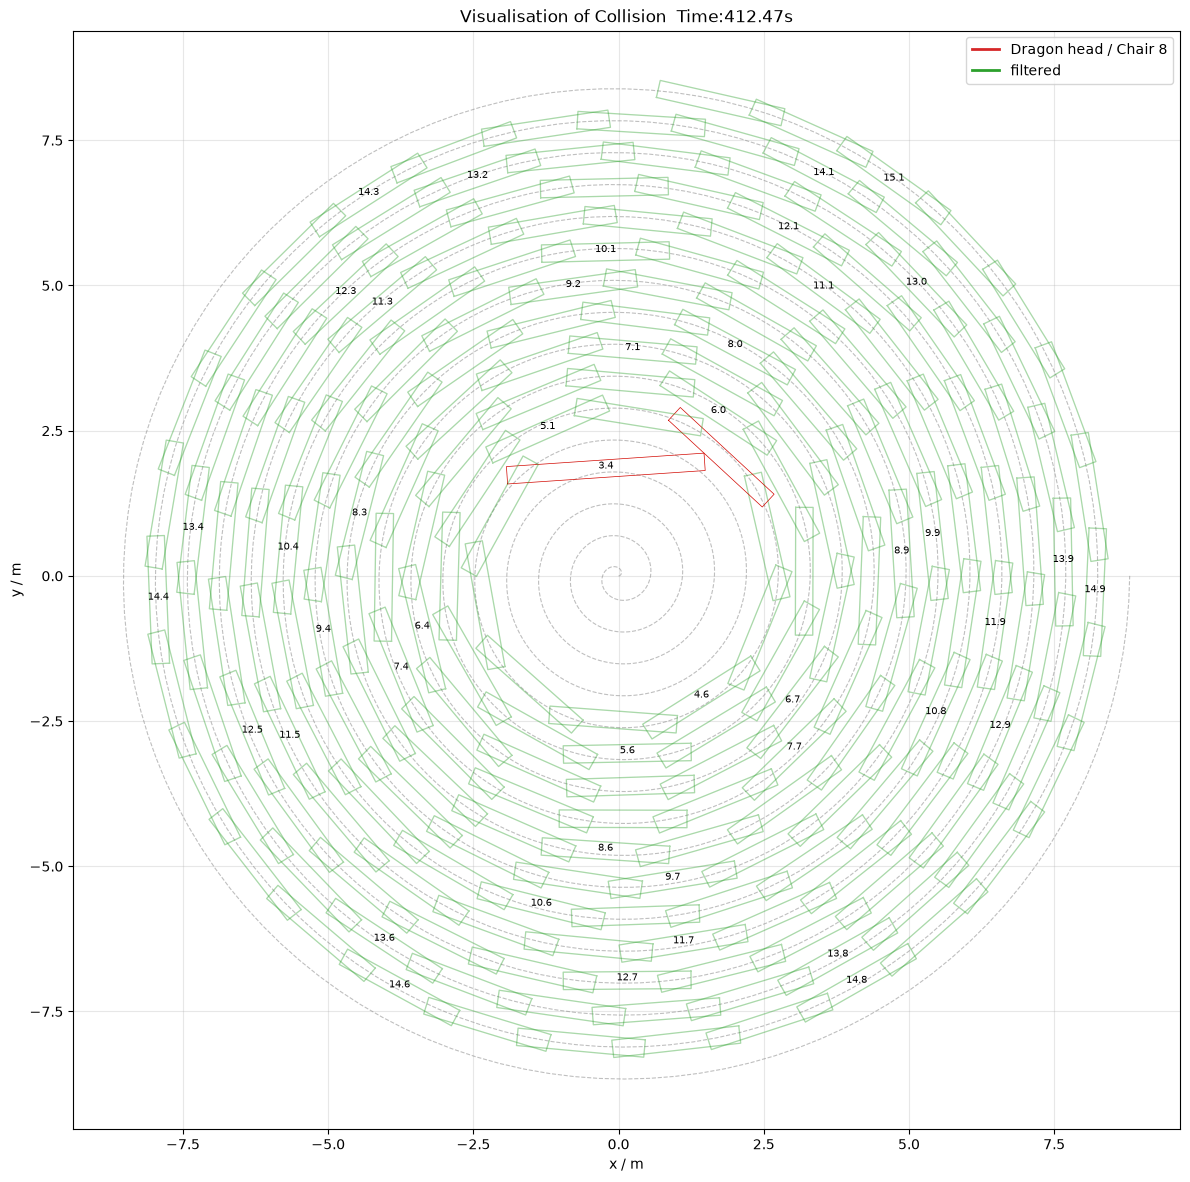

In [5]:
def plot_spiral(ax, theta_start=0, theta_end=THETA0, num_points=2000, **kwargs):

    theta = np.linspace(theta_start, theta_end, num_points)
    r = p * theta
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    ax.plot(x, y, **kwargs)


def radius_to_turn(r):
    theta = r / p
    return theta / (2 * np.pi)

def plot_obb(ax, rect, color="red", alpha=0.6, linewidth=1.2):
    p0 = rect.center + rect.half_length * rect.axis_x + rect.half_width * rect.axis_y
    p1 = rect.center - rect.half_length * rect.axis_x + rect.half_width * rect.axis_y
    p2 = rect.center - rect.half_length * rect.axis_x - rect.half_width * rect.axis_y
    p3 = rect.center + rect.half_length * rect.axis_x - rect.half_width * rect.axis_y
    verts = np.array([p0, p1, p2, p3, p0])
    ax.plot(verts[:, 0], verts[:, 1], color=color, alpha=alpha, linewidth=linewidth)


def visualize_filter_process(x_handle, y_handle , time):
    rects = build_rectangles(x_handle, y_handle)
    fig, ax = plt.subplots(figsize=(12, 12))

    plot_spiral(ax, theta_start=0, theta_end=THETA0,linestyle="--", linewidth=0.8, color="gray", alpha=0.5)

    for idx, rect in enumerate(rects):
        r_center = np.hypot(rect.center[0], rect.center[1])
        turn = radius_to_turn(r_center)

        if idx == 0 or idx == 8:
            plot_obb(ax, rect, color="#d20700", alpha=1.0 , linewidth = 0.5)
        else:
            plot_obb(ax, rect, color="#2ca02c", alpha=0.4 , linewidth = 0.95)

        # 每 5 个标记一次圈号
        if idx % 5 == 0:
            ax.text(rect.center[0], rect.center[1], f"{turn:.1f}", fontsize=7, ha="center")

    # 坐标轴设置
    ax.set_aspect("equal", "box")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("x / m")
    ax.set_ylabel("y / m")
    ax.set_title(f"Visualisation of Collision  Time:{time}s")

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color="#d62728", lw=2, label="Dragon head / Chair 8"),
        Line2D([0], [0], color="#2ca02c", lw=2, label="filtered"),
    ]
    ax.legend(handles=legend_elements, loc="upper right")

    plt.tight_layout()
    plt.savefig(f"pictures/collision_filter_vis_{time}.png", dpi=300, bbox_inches="tight")
    plt.show()
    return fig


if __name__ == "__main__":
    time_display = [412.47]
    for t in time_display:
        theta_t, x_t, y_t = solve_positions(t)
        fig = visualize_filter_process(x_t, y_t , t)
    plt.close(fig)


def visualize_filter_process_subax(x_handle, y_handle , time , ax):
    rects = build_rectangles(x_handle, y_handle)
    plot_spiral(ax, theta_start=0, theta_end=THETA0,linestyle="--", linewidth=0.8, color="gray", alpha=0.5)

    for idx, rect in enumerate(rects):
        r_center = np.hypot(rect.center[0], rect.center[1])
        turn = radius_to_turn(r_center)

        if idx == 0 or idx == 8:
            plot_obb(ax, rect, color="#d20700", alpha=1.0 , linewidth = 0.4)
        else:
            plot_obb(ax, rect, color="#2ca02c", alpha=0.4 , linewidth = 0.95)

        # 每 5 个标记一次圈号
        if idx % 5 == 0:
            ax.text(rect.center[0], rect.center[1], f"{turn:.1f}", fontsize=7, ha="center")

    # 坐标轴设置
    ax.set_aspect("equal", "box")
    ax.grid(True, alpha=0.3)
    ax.set_xlabel("x / m")
    ax.set_ylabel("y / m")
    ax.set_title(f"Visualisation of Collision  Time:{time}s")

    from matplotlib.lines import Line2D
    legend_elements = [
        Line2D([0], [0], color="#d62728", lw=2, label="Dragon head / Chair 8"),
        Line2D([0], [0], color="#2ca02c", lw=2, label="filtered"),
    ]
    ax.legend(handles=legend_elements, loc="upper right")
    
    


if __name__ == "__main__":
    time_display = [410 , 411 , 412 , 413]
    fig , axes = plt.subplots(2 , 2 , figsize=(20 , 20))
    for t , ax in zip(time_display , axes.flatten()):
        theta , x_t , y_t = solve_positions(t)
        visualize_filter_process_subax(x_t , y_t , t , ax)
    plt.savefig("pictures/collision_visualization_group.png")
    plt.show()
    plt.close(fig)

In [ ]:
# new tools

def solve_positions_from_theta(theta_head):

    theta = np.zeros(N_HANDLES)

    # 龙头前把手
    theta[0] = theta_head

    # 龙头后把手
    theta[1] = next_theta(theta[0] , HEAD_HANDLE_DISTANCE)

    # 龙身
    for i in range(2, N_HANDLES):
        theta[i] = next_theta(theta[i - 1] , BODY_HANDLE_DISTANCE)
 
    xy = np.array([position(th) for th in theta])

    return theta, xy[:, 0], xy[:, 1]



def has_collision_theta(theta_head):
    theta, x, y = solve_positions_from_theta(theta_head)

    return detect_collision(x,y,theta)

def find_first_collision_theta(theta_start , theta_end , dtheta=0.2 , tol=1e-5):

    theta_prev = theta_start

    collision, pair = has_collision_theta(theta_prev)

    if collision:
        return theta_prev, pair

    while theta_prev > theta_end:

        theta_next = max(theta_prev - dtheta , theta_end)

        collision, pair = has_collision_theta(theta_next)

        if collision:
            left = theta_next
            right = theta_prev
            collision_pair = pair

            while right - left > tol:

                mid = (left + right) / 2
                collision_mid, pair_mid = \
                    has_collision_theta(mid)

                if collision_mid:
                    left = mid
                    if pair_mid is not None:
                        collision_pair = pair_mid
                else:
                    right = mid
            return left, collision_pair
        theta_prev = theta_next
    return None, None

## Problem3 
需要PITCH_NEW 
初始位置theta0只需使p_new * theta0 > 9m即可

In [ ]:
#新参数
TURNING_RADIUS = 4.5  

In [ ]:
def head_turning_state():

    theta_turn = TURNING_RADIUS / p

    if theta_turn >= THETA0:
        return None, None

    t_turn = arc_length(theta_turn , THETA0)
    return theta_turn, t_turn

def check_pitch(pitch_new , dtheta=0.1 , tol=1e-5):

    global p
    p = pitch_new

    theta_turn = TURNING_RADIUS / p

    if theta_turn >= THETA0:
        return {
            "feasible": False,
            "pitch": p,
            "theta_turn": None,
            "t_turn": None,
            "collision_time": None,
            "collision_pair": None
        }

    # --------------------------------------------
    # 搜索首次碰撞
    # --------------------------------------------

    collision_theta, collision_pair = find_first_collision_theta(THETA0 , theta_turn , dtheta=dtheta , tol=tol)

    # --------------------------------------------
    # 发生碰撞
    # --------------------------------------------

    if collision_theta is not None:

        collision_time = arc_length(collision_theta , THETA0)
        t_turn = arc_length(theta_turn , THETA0)

        return {
            "feasible": False,
            "pitch": p,
            "theta_turn": theta_turn,
            "t_turn": t_turn,
            "collision_time": collision_time,
            "collision_pair": collision_pair
        }

    # --------------------------------------------
    # 全程没有碰撞
    # --------------------------------------------

    t_turn = arc_length(theta_turn , THETA0)

    return {
        "feasible": True,
        "pitch": p,
        "theta_turn": theta_turn,
        "t_turn": t_turn,
        "collision_time": None,
        "collision_pair": None
    }

def find_minimum_pitch(p_low , p_high , iterations=15 , dtheta=0.15 , tol=1e-6 ):

    result_low = check_pitch(p_low , dtheta = dtheta , tol=tol)
    result_high = check_pitch(p_high , dtheta=dtheta , tol=tol)

    print(
        f"p_low  = {p_low:.6f}, "
        f"feasible = {result_low['feasible']}"
    )

    print(
        f"p_high = {p_high:.6f}, "
        f"feasible = {result_high['feasible']}"
    )

    if result_low["feasible"]:
        raise ValueError("p_low 已经可行，请减小 p_low。")

    if not result_high["feasible"]:
        raise ValueError("p_high 仍不可行，请增大 p_high。")

    for i in range(iterations):

        p_mid = (p_low + p_high) / 2
        result = check_pitch(p_mid , dtheta = dtheta , tol = tol)

        print(
            f"[{i + 1:02d}/{iterations}] "
            f"p = {p_mid:.10f} "
            f"-> {result['feasible']}"
        )

        if result["feasible"]:
            p_high = p_mid
        else:
            p_low = p_mid

    return p_high

if __name__ == "__main__":
    p_min = find_minimum_pitch(0.05 , 0.10 , iterations = 25 , dtheta = 0.15 , tol = 1e-6)
    print(f"最小可行的 p = {p_min:.6f}")

PITCH_MIN = p_min * np.pi * 2
print(f"最小可行的 PITCH = {PITCH_MIN:.6f}")




p_low  = 0.050000, feasible = False
p_high = 0.100000, feasible = True
[01/25] p = 0.0750000000 -> True
[02/25] p = 0.0625000000 -> False
[03/25] p = 0.0687500000 -> False
[04/25] p = 0.0718750000 -> True
[05/25] p = 0.0703125000 -> False
[06/25] p = 0.0710937500 -> False
[07/25] p = 0.0714843750 -> False
[08/25] p = 0.0716796875 -> True
[09/25] p = 0.0715820313 -> False
[10/25] p = 0.0716308594 -> False
[11/25] p = 0.0716552734 -> False
[12/25] p = 0.0716674805 -> False
[13/25] p = 0.0716735840 -> True
[14/25] p = 0.0716705322 -> False
[15/25] p = 0.0716720581 -> False
[16/25] p = 0.0716728210 -> True
[17/25] p = 0.0716724396 -> False
[18/25] p = 0.0716726303 -> True
[19/25] p = 0.0716725349 -> True
[20/25] p = 0.0716724873 -> True
[21/25] p = 0.0716724634 -> True
[22/25] p = 0.0716724515 -> False
[23/25] p = 0.0716724575 -> False
[24/25] p = 0.0716724604 -> False
[25/25] p = 0.0716724619 -> False
最小可行的 p = 0.071672
最小可行的 PITCH = 0.450331


In [ ]:
from matplotlib.patches import Circle as Circle_plt

# def visualize_critical_collision(pitch, dtheta=0.02, tol=1e-6):
#     global p
#     p = pitch

#     theta_turn = TURNING_RADIUS / p

#     collision_theta, collision_pair = find_first_collision_theta(
#         THETA0,
#         theta_turn,
#         dtheta=dtheta,
#         tol=tol
#     )

#     if collision_theta is None:
#         print(f"p = {p:.10f} 在当前精度下未检测到碰撞")
#         return  {
#         "pitch": p,
#         "collision_theta": collision_theta,
#         "collision_time": collision_time,
#         "collision_pair": collision_pair,
#         "rectangles": rectangles,
#         "theta": theta,
#         "x": x,
#         "y": y
#     }

#     collision_time = arc_length(collision_theta, THETA0)

#     theta, x, y = solve_positions_from_theta(collision_theta)
#     rectangles = build_rectangles(x, y)

#     fig, ax = plt.subplots(figsize=(12, 12))

#     # -----------------------------
#     # 螺线
#     # -----------------------------
#     plot_spiral(
#         ax,
#         theta_start=0,
#         theta_end=THETA0,
#         linestyle="--",
#         linewidth=0.8,
#         alpha=0.4
#     )

#     # -----------------------------
#     # 9 m 转向空间
#     # -----------------------------
#     turning_circle = Circle_plt(
#         (0, 0),
#         TURNING_RADIUS,
#         fill=False,
#         linewidth=2,
#         linestyle="--"
#     )
#     ax.add_patch(turning_circle)

#     # -----------------------------
#     # 绘制所有木凳
#     # -----------------------------
#     for i, rect in enumerate(rectangles):
#         plot_obb(
#             ax,
#             rect,
#             alpha=0.25,
#             linewidth=0.7
#         )

#     # -----------------------------
#     # 高亮碰撞木凳
#     # -----------------------------
#     i, j = collision_pair

#     plot_obb(
#         ax,
#         rectangles[i],
#         alpha=1.0,
#         linewidth=3.0
#     )

#     plot_obb(
#         ax,
#         rectangles[j],
#         alpha=1.0,
#         linewidth=3.0
#     )

#     # -----------------------------
#     # 标出木凳中心
#     # -----------------------------
#     for index in [i, j]:
#         center = rectangles[index].center

#         ax.scatter(
#             center[0],
#             center[1],
#             s=80,
#             zorder=10
#         )

#         ax.text(
#             center[0],
#             center[1],
#             f"  Bench {index}",
#             fontsize=12,
#             fontweight="bold",
#             zorder=11
#         )

#     # -----------------------------
#     # 碰撞点附近连线
#     # -----------------------------
#     center_i = rectangles[i].center
#     center_j = rectangles[j].center

#     ax.plot(
#         [center_i[0], center_j[0]],
#         [center_i[1], center_j[1]],
#         linestyle=":",
#         linewidth=2
#     )

#     # -----------------------------
#     # 图形设置
#     # -----------------------------
#     ax.set_aspect("equal", "box")

#     ax.set_xlabel("x / m")
#     ax.set_ylabel("y / m")

#     ax.set_title(
#         f"Critical Collision\n"
#         f"p = {p:.10f}, "
#         f"t = {collision_time:.6f} s, "
#         f"Bench {i} ↔ Bench {j}"
#     )

#     ax.grid(True, alpha=0.3)

#     plt.tight_layout()
#     plt.show()

#     print("=" * 60)
#     print(f"pitch           = {p:.10f}")
#     print(f"collision time  = {collision_time:.8f} s")
#     print(f"collision theta = {collision_theta:.8f}")
#     print(f"collision pair  = ({i}, {j})")
#     print("=" * 60)

#     return {
#         "pitch": p,
#         "collision_theta": collision_theta,
#         "collision_time": collision_time,
#         "collision_pair": collision_pair,
#         "rectangles": rectangles,
#         "theta": theta,
#         "x": x,
#         "y": y
#     }


# def visualize_collision_detail(result, padding=0.5):
#     rectangles = result["rectangles"]
#     i, j = result["collision_pair"]

#     rect_i = rectangles[i]
#     rect_j = rectangles[j]

#     centers = np.array([
#         rect_i.center,
#         rect_j.center
#     ])

#     xmin = centers[:, 0].min() - padding
#     xmax = centers[:, 0].max() + padding
#     ymin = centers[:, 1].min() - padding
#     ymax = centers[:, 1].max() + padding

#     fig, ax = plt.subplots(figsize=(8, 8))

#     # 两个碰撞木凳
#     plot_obb(
#         ax,
#         rect_i,
#         alpha=1.0,
#         linewidth=3.0
#     )

#     plot_obb(
#         ax,
#         rect_j,
#         alpha=1.0,
#         linewidth=3.0
#     )

#     # 中心点
#     ax.scatter(
#         rect_i.center[0],
#         rect_i.center[1],
#         s=100,
#         zorder=10
#     )

#     ax.scatter(
#         rect_j.center[0],
#         rect_j.center[1],
#         s=100,
#         zorder=10
#     )

#     # 中心连线
#     ax.plot(
#         [rect_i.center[0], rect_j.center[0]],
#         [rect_i.center[1], rect_j.center[1]],
#         linestyle="--",
#         linewidth=1.5
#     )

#     # 标签
#     ax.text(
#         rect_i.center[0],
#         rect_i.center[1],
#         f"Bench {i}",
#         fontsize=12,
#         fontweight="bold"
#     )

#     ax.text(
#         rect_j.center[0],
#         rect_j.center[1],
#         f"Bench {j}",
#         fontsize=12,
#         fontweight="bold"
#     )

#     ax.set_xlim(xmin, xmax)
#     ax.set_ylim(ymin, ymax)

#     ax.set_aspect("equal", "box")
#     ax.grid(True, alpha=0.3)

#     ax.set_xlabel("x / m")
#     ax.set_ylabel("y / m")

#     ax.set_title(
#         f"Collision Detail: Bench {i} ↔ Bench {j}"
#     )

#     plt.tight_layout()
#     plt.show()




In [ ]:
def visualize_turning_state(pitch):
    """
    可视化：
    龙头到达 r = 4.5 m 转弯边界时的队伍状态。

    总览图：
        - 所有普通木凳：绿色
        - 龙头 Bench 0：红色突出
        - Bench 16：蓝色突出
        - 显示 9 m 转弯圆
        - 左上角显示 Bench 0 与 Bench 16 的特写

    特写图：
        - 只显示 Bench 0（龙头）
        - 只显示 Bench 16
    """

    global p
    p = pitch

    # =========================================================
    # 1. 计算龙头到达转弯边界时的 theta 和时间
    # =========================================================

    theta_turn = TURNING_RADIUS / p

    if theta_turn >= THETA0:
        print("错误：当前 pitch 太小，龙头初始位置已经位于转弯区域内。")
        return

    t_turn = arc_length(theta_turn, THETA0)

    # =========================================================
    # 2. 计算此时所有把手的位置
    # =========================================================

    theta, x, y = solve_positions_from_theta(theta_turn)

    # =========================================================
    # 3. 创建木凳 OBB
    # =========================================================

    rectangles = build_rectangles(x, y)

    # =========================================================
    # 4. 检查碰撞
    # =========================================================

    collision, collision_pair = detect_collision(
        x,
        y,
        theta
    )

    # =========================================================
    # 5. 创建画布
    # =========================================================

    fig, ax = plt.subplots(
        figsize=(12, 10)
    )

    # 绘制阿基米德螺线

    plot_spiral(ax, theta_start=0, theta_end=THETA0,linestyle="--", linewidth=0.8, color="gray", alpha=0.5)

    # =========================================================
    # 7. 绘制 9 m 转弯区域
    # =========================================================

    turning_circle = Circle_plt(
        (0, 0),
        TURNING_RADIUS,
        fill=False,
        linestyle="--",
        linewidth=1.5,
        alpha=0.7
    )

    ax.add_patch(turning_circle)

    # 转弯圆中心
    ax.scatter(
        0,
        0,
        s=40,
        zorder=5
    )

    # =========================================================
    # 8. 绘制所有木凳
    #
    # 普通木凳：绿色
    # 龙头 Bench 0：红色
    # Bench 16：蓝色
    # =========================================================

    for i, rect in enumerate(rectangles):

        # -----------------------------------------------------
        # 龙头 Bench 0
        # -----------------------------------------------------
        if i == 0:

            plot_obb(
                ax,
                rect,
                color="red",
                alpha=0.8,
                linewidth=1
            )

            ax.scatter(
                rect.center[0],
                rect.center[1],
                s=30,
                color="red",
                zorder=10,
                alpha=0.6
            )

            ax.text(
                rect.center[0],
                rect.center[1],
                " Dragon Head \n  Bench 0",
                fontsize=11,
                fontweight="bold",
                color="red",
                zorder=11,
                alpha=0.6
            )
        # -----------------------------------------------------
        # Bench 16
        # -----------------------------------------------------
        elif i == 16:

            plot_obb(
                ax,
                rect,
                color="blue",
                alpha=0.8,
                linewidth=1
            )

            ax.scatter(
                rect.center[0],
                rect.center[1],
                s=30,
                color="blue",
                zorder=10
            )

            ax.text(
                rect.center[0],
                rect.center[1],
                "  Bench 16",
                fontsize=11,
                color="blue",
                zorder=11
            )

        # -----------------------------------------------------
        # 普通木凳
        # -----------------------------------------------------
        else:

            plot_obb(
                ax,
                rect,
                color="green",
                alpha=0.4,
                linewidth=1.0
            )

    # =========================================================
    # 9. 标记龙头当前位置
    # =========================================================

    head_position = np.array([
        x[0],
        y[0]
    ])

    ax.scatter(
        head_position[0],
        head_position[1],
        s=100,
        facecolors="none",
        edgecolors="red",
        linewidths=1,
        zorder=12
    )

    # =========================================================
    # 10. 固定特写区域：
    #     龙头 Bench 0 + Bench 16
    # =========================================================

    i = 0
    j = 16

    rect_i = rectangles[i]
    rect_j = rectangles[j]

    centers = np.array([
        rect_i.center,
        rect_j.center
    ])

    # ---------------------------------------------------------
    # 特写区域范围
    # ---------------------------------------------------------

    xmin = centers[:, 0].min() - 0.8
    xmax = centers[:, 0].max() + 0.8

    ymin = centers[:, 1].min() - 0.8
    ymax = centers[:, 1].max() + 0.8

    # =========================================================
    # 11. 在总览图中画出特写框
    # =========================================================

    from matplotlib.patches import Rectangle as MplRectangle

    zoom_box = MplRectangle(
        (xmin, ymin),
        xmax - xmin,
        ymax - ymin,
        fill=False,
        linewidth=2.5,
        linestyle=":"
    )

    ax.add_patch(zoom_box)

    # =========================================================
    # 12. 创建左上角特写
    # =========================================================

    inset = ax.inset_axes(
        [0.04, 0.58, 0.38, 0.38]
    )

    # =========================================================
    # 13. 特写中绘制 Bench 0
    # =========================================================

    plot_obb(
        inset,
        rect_i,
        color="red",
        alpha=1.0,
        linewidth=3.5
    )

    # =========================================================
    # 14. 特写中绘制 Bench 16
    # =========================================================

    plot_obb(
        inset,
        rect_j,
        color="blue",
        alpha=1.0,
        linewidth=2
    )

    # =========================================================
    # 15. 特写中的中心点
    # =========================================================

    inset.scatter(
        rect_i.center[0],
        rect_i.center[1],
        s=90,
        color="red",
        zorder=10
    )

    inset.scatter(
        rect_j.center[0],
        rect_j.center[1],
        s=90,
        color="blue",
        zorder=10
    )

    # =========================================================
    # 16. 特写中的文字标签
    # =========================================================

    inset.text(
        rect_i.center[0],
        rect_i.center[1],
        "  Dragon head\n  Bench 0",
        fontsize=10,
        fontweight="bold",
        color="red",
        zorder=11
    )

    inset.text(
        rect_j.center[0],
        rect_j.center[1],
        "  Bench 16",
        fontsize=10,
        fontweight="bold",
        color="blue",
        zorder=11
    )

    # =========================================================
    # 17. 特写中画两木凳中心连线
    # =========================================================

    inset.plot(
        [rect_i.center[0], rect_j.center[0]],
        [rect_i.center[1], rect_j.center[1]],
        linestyle="--",
        linewidth=1.5,
        alpha=0.8
    )

    # =========================================================
    # 18. 特写范围
    # =========================================================

    inset.set_xlim(
        xmin,
        xmax
    )

    inset.set_ylim(
        ymin,
        ymax
    )

    inset.set_aspect(
        "equal",
        adjustable="box"
    )

    inset.grid(
        True,
        alpha=0.3
    )

    # 19. 特写标题

    inset.set_title(
        "Specification of Bench 0 / Bench 16 ",
        fontsize=11,
        fontweight="bold"
    )

    # 20. 总览图标题

    if collision:

        title = (
            f"State at turning point\n"
            f"p = {pitch:.6f} m    "
            f"t = {t_turn:.3f} s    "
            f"Collision:Bench {collision_pair[0]} ↔ "
            f"Bench {collision_pair[1]}"
        )

    else:

        title = (
            f"State at turning point\n"
            f"p = {pitch:.6f} m    "
            f"t = {t_turn:.3f} s    "
            f"No collision"
        )

    ax.set_title(
        title,
        fontsize=15,
        fontweight="bold",
        pad=15
    )

    # =========================================================
    # 21. 坐标轴
    # =========================================================

    ax.set_xlabel(
        "x / m",
        fontsize=12
    )

    ax.set_ylabel(
        "y / m",
        fontsize=12
    )

    ax.set_aspect(
        "equal",
        adjustable="box"
    )

    ax.grid(
        True,
        alpha=0.25
    )

    # =========================================================
    # 22. 坐标范围
    # =========================================================

    margin = 2.0

    all_x = np.asarray(x)
    all_y = np.asarray(y)

    ax.set_xlim(
        all_x.min() - margin,
        all_x.max() + margin
    )

    ax.set_ylim(
        all_y.min() - margin,
        all_y.max() + margin
    )

    # =========================================================
    # 23. 图例
    # =========================================================

    from matplotlib.lines import Line2D

    legend_elements = [
        Line2D(
            [0],
            [0],
            color="green",
            linewidth=2,
            label="Bench"
        ),

        Line2D(
            [0],
            [0],
            color="red",
            linewidth=3,
            label="Dragon head Bench 0"
        ),

        Line2D(
            [0],
            [0],
            color="blue",
            linewidth=3,
            label="Bench 16"
        ),

        Line2D(
            [0],
            [0],
            linestyle="--",
            color="black",
            linewidth=2,
            label="9 m Turning Verge"
        )
    ]

    ax.legend(
        handles=legend_elements,
        loc="lower right",
        fontsize=10
    )

    # =========================================================
    # 24. 调整布局并显示
    # =========================================================

    plt.tight_layout()

    plt.show()

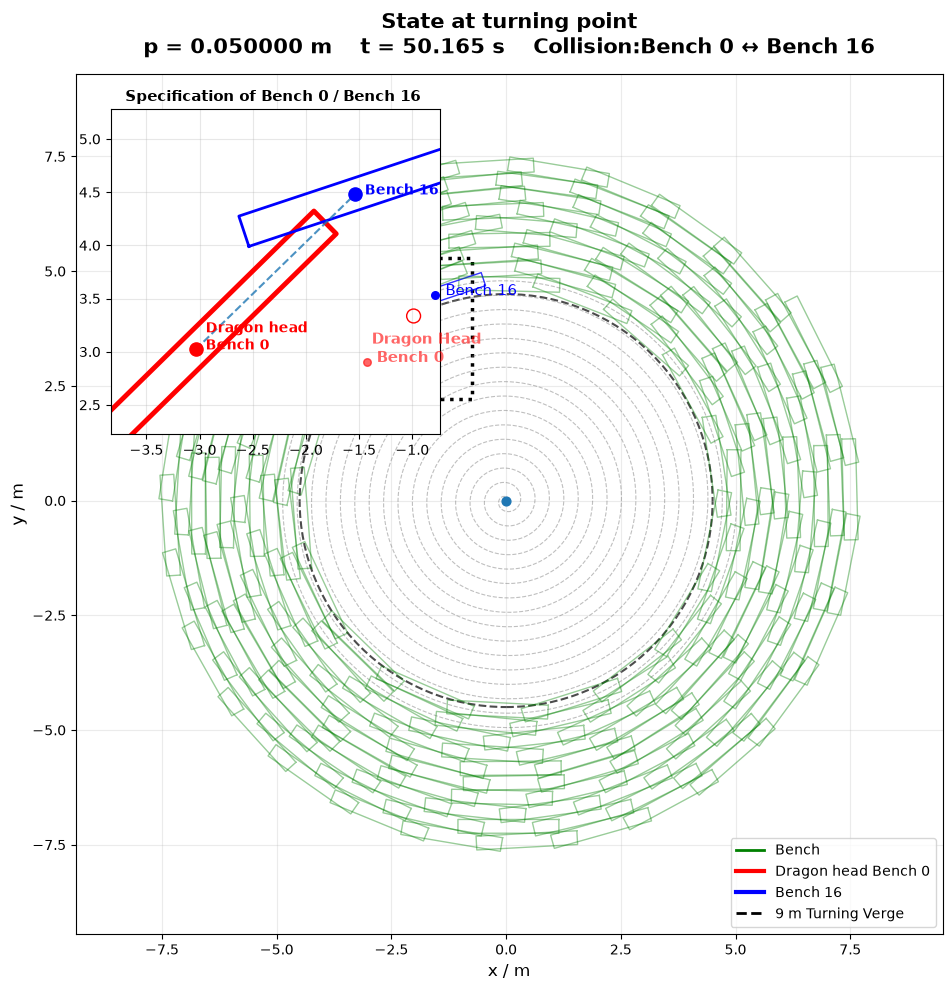

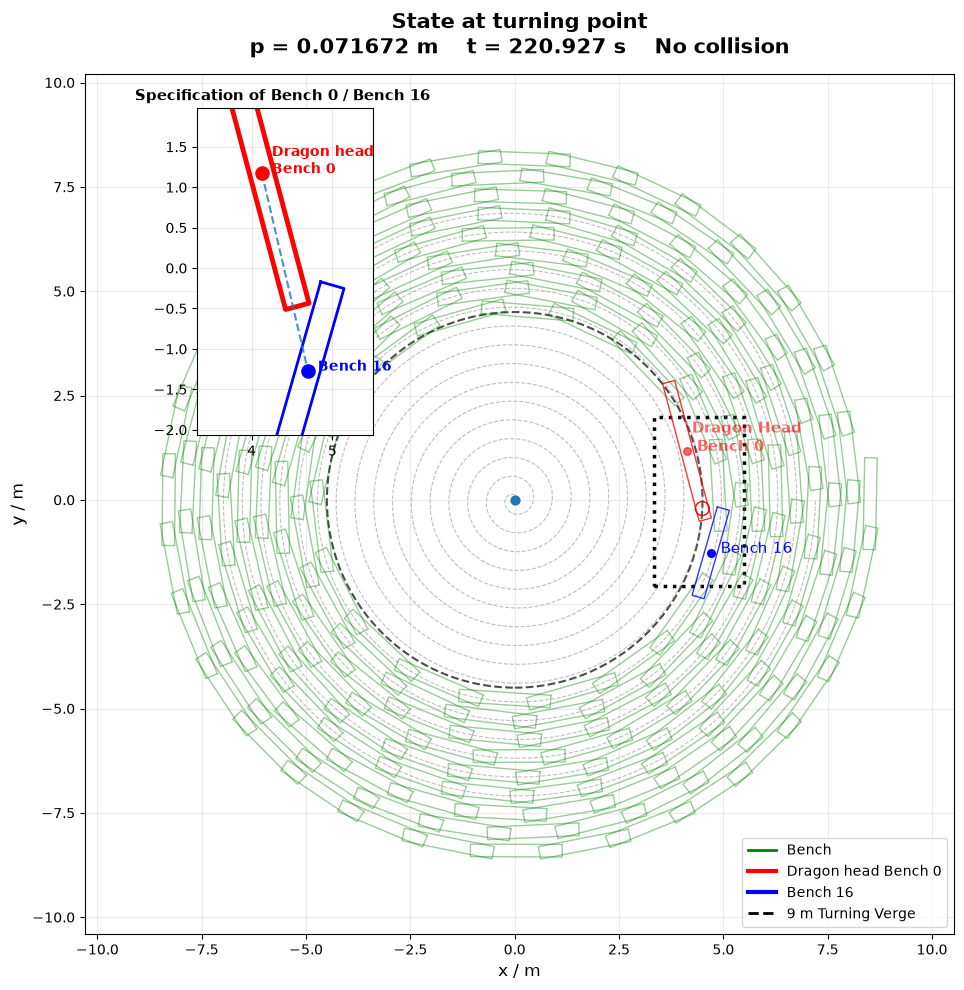

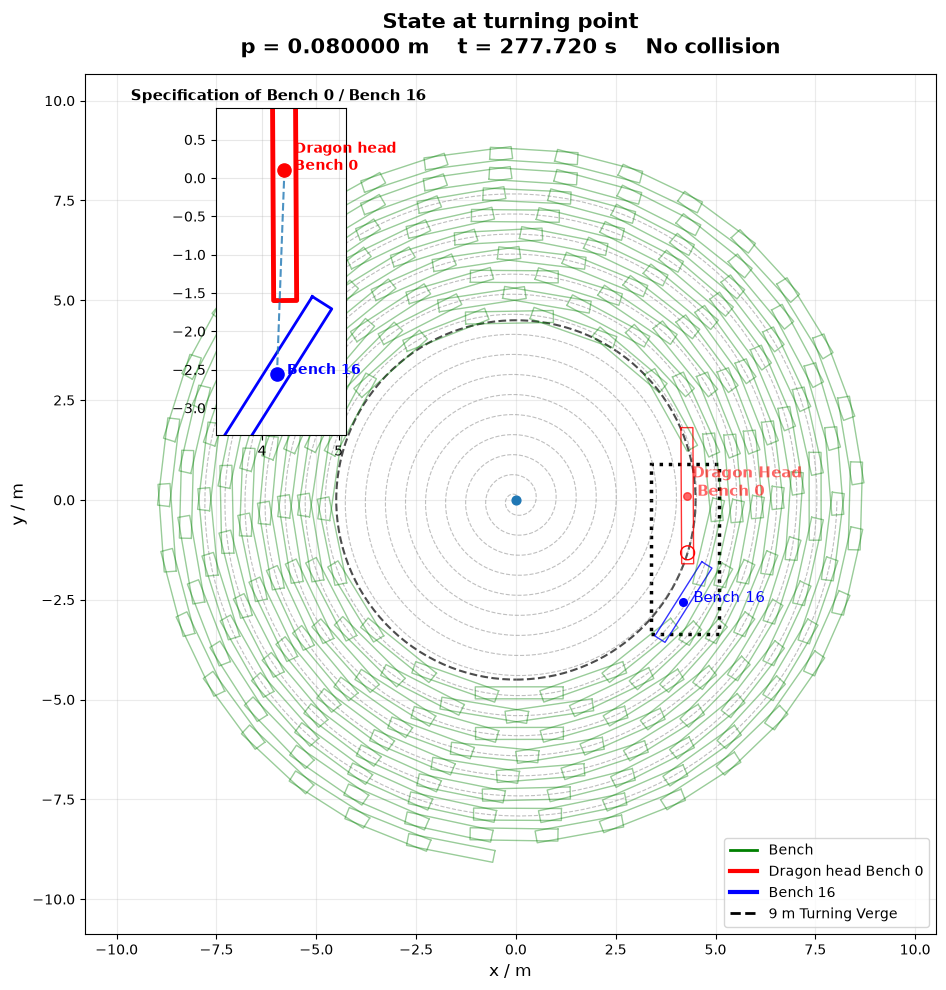

In [ ]:
if __name__ == "__main__":
    p_sample = [0.05 , p_min , 0.08]


    # ==========================================
    # 绘制龙头到达 r = 4.5 m 时的状态
    # ==========================================
    for p_s in p_sample:
        result = visualize_turning_state(p_s)

## Problem 4
### 参数 + 使用的库

In [ ]:
PITCH = 1.70
TURNING_RADIUS = 0.451

在100时刻前发生碰撞，碰撞对为(0, 14)
Current pair:(0, 14)
Current pair:None
Current pair:None
Current pair:None
Current pair:None


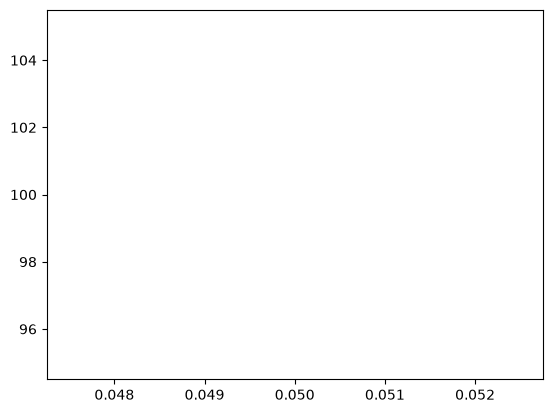

In [8]:
# p-t关系图

p_sample = np.linspace(0.05 , 0.5 , 5)
t_sample_f = []
#PITCH_sample = p_sample * np.pi * 2
for p_s in p_sample:
    global p
    p = p_s
    t_s , pair = find_first_collision(100) 
    print(f"Current pair:{pair}")
    t_sample_f.append(t_s)
t_sample = np.array(t_sample_f)
plt.plot(p_sample , t_sample)
plt.show()